# Regularisation: Ridge, Lasso, and Elastic Net

## Learning Objectives

- Understand the bias–variance tradeoff and why OLS can overfit.
- Derive the Ridge (L2) and Lasso (L1) estimators mathematically.
- Implement Ridge regression from scratch using the normal equations.
- Implement Lasso via coordinate descent from scratch.
- Use scikit-learn's `RidgeCV`, `LassoCV`, `ElasticNetCV` for automatic tuning.
- Connect regularisation to Bayesian priors.

## Prerequisites

- **Module 06:** Multiple linear regression, OLS in matrix form.
- **Module 04:** Maximum likelihood estimation.

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. From OLS to Regularisation

### Recap: Ordinary Least Squares

In Module 06 we derived the OLS estimator for the linear model

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I}_n),
$$

where $\mathbf{X} \in \mathbb{R}^{n \times p}$ is the design matrix (with $n$ observations and $p$ predictors), $\boldsymbol{\beta} \in \mathbb{R}^p$ is the coefficient vector, and $\mathbf{y} \in \mathbb{R}^n$ is the response. The OLS solution minimises the residual sum of squares:

$$
\hat{\boldsymbol{\beta}}^{\text{OLS}} = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}.
$$

OLS is the **Best Linear Unbiased Estimator** (BLUE) by the Gauss–Markov theorem: among all linear unbiased estimators, it has the smallest variance. This sounds ideal, but the key word is *unbiased*. In high-dimensional settings, unbiasedness can be a liability.

### When OLS Fails

Consider what happens when:

1. **$p$ is large relative to $n$:** The matrix $\mathbf{X}^\top\mathbf{X}$ becomes ill-conditioned or singular. If $p > n$, the system is underdetermined and $\mathbf{X}^\top\mathbf{X}$ is not invertible at all — OLS has infinitely many solutions.

2. **Predictors are highly correlated (multicollinearity):** Even when $p < n$, if columns of $\mathbf{X}$ are nearly linearly dependent, the eigenvalues of $\mathbf{X}^\top\mathbf{X}$ span several orders of magnitude. The inverse amplifies noise in the small-eigenvalue directions, producing coefficient estimates with enormous variance.

3. **Many irrelevant predictors:** If only a few of the $p$ predictors truly affect $\mathbf{y}$, OLS still estimates all $p$ coefficients, fitting noise in the irrelevant predictors. The model *memorises* training-set idiosyncrasies that do not generalise.

In all three cases, OLS **overfits**: it achieves low training error but poor predictive performance on new data.

### A Concrete Demonstration

Let us construct a toy example that makes overfitting obvious. We generate $n = 50$ observations with $p = 40$ predictors, but only the first 5 predictors have a real effect. OLS must estimate 40 coefficients from 50 data points — a recipe for overfitting.

In [ ]:
# --- Data generation: n=50, p=40, only 5 true signals ---
n_train, n_test, p = 50, 200, 40
n_signal = 5

# True coefficients: first 5 are nonzero, rest are zero
beta_true = np.zeros(p)
beta_true[:n_signal] = rng.uniform(1.5, 4.0, size=n_signal) * rng.choice(
    [-1, 1], size=n_signal
)
sigma_noise = 2.0

# Training set
X_train = rng.standard_normal((n_train, p))
y_train = X_train @ beta_true + rng.normal(0, sigma_noise, n_train)

# Test set
X_test = rng.standard_normal((n_test, p))
y_test = X_test @ beta_true + rng.normal(0, sigma_noise, n_test)

# OLS fit (using pseudoinverse for numerical stability)
beta_ols = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

# Evaluate
mse_train_ols = mean_squared_error(y_train, X_train @ beta_ols)
mse_test_ols = mean_squared_error(y_test, X_test @ beta_ols)

print(f"True coefficients (first 10):  {np.round(beta_true[:10], 2)}")
print(f"OLS  coefficients (first 10):  {np.round(beta_ols[:10], 2)}")
print(f"")
print(f"OLS Train MSE: {mse_train_ols:.2f}")
print(f"OLS Test  MSE: {mse_test_ols:.2f}")
print(f"Irreducible noise σ² = {sigma_noise**2:.1f}")

True coefficients (first 10):  [3.43 2.6  3.65 3.24 1.74 0.   0.   0.   0.   0.  ]
OLS  coefficients (first 10):  [ 3.69  2.37  3.77  2.68  1.51  0.08  0.78 -0.26  0.33  0.05]

OLS Train MSE: 1.32
OLS Test  MSE: 8.38
Irreducible noise σ² = 4.0


The training MSE is deceptively low — OLS fits the noise perfectly. But the test MSE is much higher, revealing that OLS has overfit. The model has learned patterns in the training noise rather than the true underlying relationship.

The core idea of **regularisation** is to constrain or penalise the coefficient vector $\boldsymbol{\beta}$, deliberately introducing a small amount of bias in exchange for a large reduction in variance. The result is better generalisation.

---

## 2. The Bias–Variance Tradeoff

Before we introduce specific regularisation methods, we need to formalise *why* trading bias for variance can improve prediction.

### MSE Decomposition

Consider a fixed test point $\mathbf{x}_0$. The true response is $y_0 = f(\mathbf{x}_0) + \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. We train a model $\hat{f}$ on a random training set and predict $\hat{f}(\mathbf{x}_0)$. The expected prediction error (over both training sets and test noise) decomposes as:

$$
\mathbb{E}\bigl[(y_0 - \hat{f}(\mathbf{x}_0))^2\bigr] = \underbrace{\bigl(\mathbb{E}[\hat{f}(\mathbf{x}_0)] - f(\mathbf{x}_0)\bigr)^2}_{\text{Bias}^2} + \underbrace{\text{Var}\bigl(\hat{f}(\mathbf{x}_0)\bigr)}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}.
$$

**Derivation.** Let $\mu = \mathbb{E}[\hat{f}(\mathbf{x}_0)]$ and $f_0 = f(\mathbf{x}_0)$. Then:

$$
\begin{align}
\mathbb{E}[(y_0 - \hat{f}(\mathbf{x}_0))^2]
&= \mathbb{E}[(f_0 + \varepsilon - \hat{f}(\mathbf{x}_0))^2] \\
&= \mathbb{E}[(f_0 - \hat{f}(\mathbf{x}_0))^2] + 2\,\mathbb{E}[(f_0 - \hat{f}(\mathbf{x}_0))\varepsilon] + \mathbb{E}[\varepsilon^2].
\end{align}
$$

Since $\varepsilon$ is independent of $\hat{f}(\mathbf{x}_0)$ and has mean zero, the cross-term vanishes and $\mathbb{E}[\varepsilon^2] = \sigma^2$. For the first term:

$$
\begin{align}
\mathbb{E}[(f_0 - \hat{f}(\mathbf{x}_0))^2]
&= \mathbb{E}[(f_0 - \mu + \mu - \hat{f}(\mathbf{x}_0))^2] \\
&= (f_0 - \mu)^2 + 2(f_0 - \mu)\,\mathbb{E}[\mu - \hat{f}(\mathbf{x}_0)] + \mathbb{E}[(\mu - \hat{f}(\mathbf{x}_0))^2] \\
&= (f_0 - \mu)^2 + 0 + \text{Var}(\hat{f}(\mathbf{x}_0)),
\end{align}
$$

since $\mathbb{E}[\mu - \hat{f}(\mathbf{x}_0)] = \mu - \mu = 0$. Combining:

$$
\boxed{\mathbb{E}[(y_0 - \hat{f}(\mathbf{x}_0))^2] = \text{Bias}^2(\hat{f}(\mathbf{x}_0)) + \text{Var}(\hat{f}(\mathbf{x}_0)) + \sigma^2.}
$$

### Implications

- **OLS** is unbiased ($\text{Bias}^2 = 0$), but in high-dimensional or collinear settings its variance can be enormous.
- **Regularised estimators** accept a small, controlled increase in $\text{Bias}^2$ in return for a much larger decrease in $\text{Var}$, yielding lower total MSE.
- The optimal tradeoff depends on the problem: more regularisation is needed when $p/n$ is large, when the signal-to-noise ratio is low, or when predictors are correlated.

### Simulation: Bias² and Variance vs. Model Complexity

The following simulation illustrates the tradeoff using polynomial regression. We fit polynomials of increasing degree $d$ to noisy data from a cubic function. For each degree, we repeat the experiment across many training sets to estimate Bias² and Variance separately.

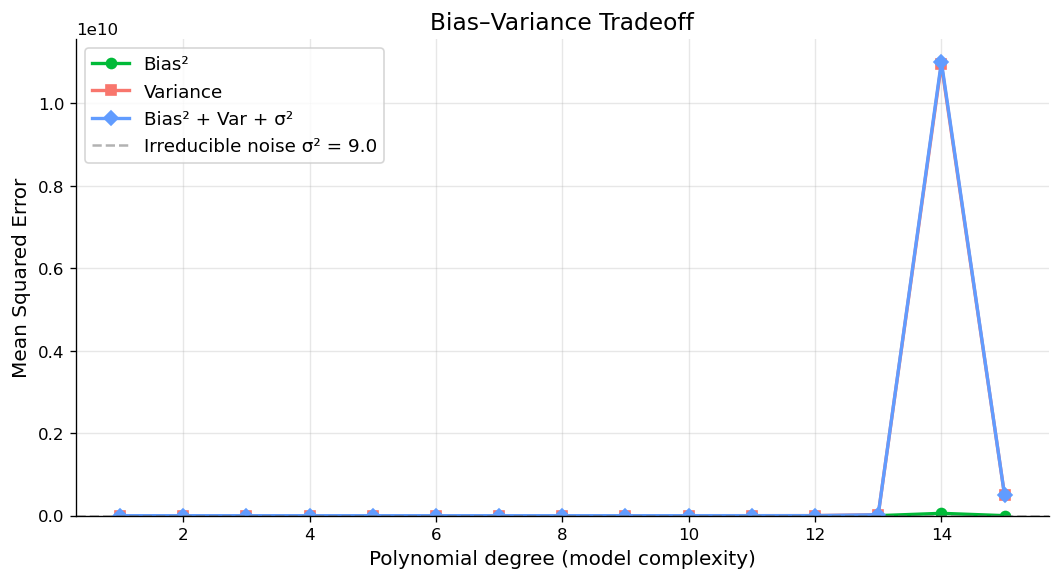

In [ ]:
# --- Bias-Variance tradeoff simulation with polynomial regression ---
def true_function(x):
    return 0.5 * x**3 - 2 * x**2 + x + 3


n_sim = 200  # number of simulated training sets
n_points = 30  # observations per training set
sigma_bv = 3.0  # noise std
degrees = range(1, 16)

# Fixed test points
x_test_bv = np.linspace(-1, 4, 50)
f_true = true_function(x_test_bv)

# Store predictions: (n_sim, n_test_points) for each degree
bias_sq_list, var_list, mse_list = [], [], []

for d in degrees:
    preds = np.zeros((n_sim, len(x_test_bv)))
    for s in range(n_sim):
        x_tr = rng.uniform(-1, 4, n_points)
        y_tr = true_function(x_tr) + rng.normal(0, sigma_bv, n_points)
        coeffs = np.polyfit(x_tr, y_tr, d)
        preds[s] = np.polyval(coeffs, x_test_bv)

    mean_pred = preds.mean(axis=0)
    bias_sq = np.mean((mean_pred - f_true) ** 2)
    variance = np.mean(preds.var(axis=0))
    total_mse = bias_sq + variance + sigma_bv**2

    bias_sq_list.append(bias_sq)
    var_list.append(variance)
    mse_list.append(total_mse)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(degrees), bias_sq_list, "o-", color=EMERALD, lw=2, label="Bias²")
ax.plot(list(degrees), var_list, "s-", color=SALMON, lw=2, label="Variance")
ax.plot(list(degrees), mse_list, "D-", color=PERIWINKLE, lw=2, label="Bias² + Var + σ²")
ax.axhline(
    sigma_bv**2,
    color="gray",
    ls="--",
    alpha=0.6,
    label=f"Irreducible noise σ² = {sigma_bv**2}",
)
ax.set_xlabel("Polynomial degree (model complexity)")
ax.set_ylabel("Mean Squared Error")
ax.set_title("Bias–Variance Tradeoff")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

The plot reveals the classic U-shape of total MSE:

- **Low complexity (small $d$):** The model is too simple to capture the true cubic relationship. Bias is high, variance is low.
- **Right complexity ($d \approx 3$):** Bias is near zero (the model class includes the true function), and variance is still modest. Total MSE is minimised.
- **High complexity (large $d$):** Bias stays near zero, but variance explodes. The model fits noise, producing wildly different predictions across training sets.

Regularisation achieves the same goal as choosing the right model complexity: it finds the sweet spot between underfitting and overfitting, but it does so by shrinking the *coefficients* rather than reducing the number of predictors.

---

## 3. Ridge Regression (L2 Penalty)

### Definition

Ridge regression augments the OLS objective with an **L2 penalty** on the coefficient vector:

$$
\hat{\boldsymbol{\beta}}^{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \|\boldsymbol{\beta}\|_2^2 \right\},
$$

where $\lambda \geq 0$ is the **regularisation parameter** (also called the penalty strength or shrinkage parameter), and $\|\boldsymbol{\beta}\|_2^2 = \sum_{j=1}^p \beta_j^2$ is the squared L2 norm of the coefficient vector.

The penalty $\lambda \|\boldsymbol{\beta}\|_2^2$ discourages large coefficients. The larger $\lambda$ is, the more aggressively the coefficients are shrunk toward zero.

### Deriving the Closed-Form Solution

Let us expand the objective and take derivatives. Write $L(\boldsymbol{\beta}) = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) + \lambda \boldsymbol{\beta}^\top\boldsymbol{\beta}$.

Expanding:

$$
L(\boldsymbol{\beta}) = \mathbf{y}^\top\mathbf{y} - 2\boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{y} + \boldsymbol{\beta}^\top\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} + \lambda \boldsymbol{\beta}^\top\boldsymbol{\beta}.
$$

Taking the gradient with respect to $\boldsymbol{\beta}$ and setting it to zero:

$$
\frac{\partial L}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^\top\mathbf{y} + 2\mathbf{X}^\top\mathbf{X}\boldsymbol{\beta} + 2\lambda\boldsymbol{\beta} = \mathbf{0}.
$$

Rearranging:

$$
(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I}_p)\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}.
$$

Since $\mathbf{X}^\top\mathbf{X}$ is positive semi-definite and $\lambda\mathbf{I}_p$ is positive definite for $\lambda > 0$, their sum is always positive definite and hence invertible. This gives the **Ridge closed-form solution**:

$$
\boxed{\hat{\boldsymbol{\beta}}^{\text{ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I}_p)^{-1}\mathbf{X}^\top\mathbf{y}.}
$$

Note the elegant structural similarity to OLS: we simply add $\lambda \mathbf{I}_p$ to $\mathbf{X}^\top\mathbf{X}$. This "ridges" the diagonal of the Gram matrix — hence the name *ridge regression*.

### Behaviour at Extreme Values of $\lambda$

- **$\lambda = 0$:** The penalty vanishes and we recover OLS: $\hat{\boldsymbol{\beta}}^{\text{ridge}} = \hat{\boldsymbol{\beta}}^{\text{OLS}}$.
- **$\lambda \to \infty$:** The penalty dominates, forcing all coefficients toward zero: $\hat{\boldsymbol{\beta}}^{\text{ridge}} \to \mathbf{0}$.

### SVD Interpretation

Let $\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{V}^\top$ be the SVD, where $\mathbf{D} = \text{diag}(d_1, \ldots, d_p)$ contains the singular values. Then:

$$
\hat{\boldsymbol{\beta}}^{\text{ridge}} = \mathbf{V} \text{diag}\!\left(\frac{d_j^2}{d_j^2 + \lambda}\right) \mathbf{V}^\top \hat{\boldsymbol{\beta}}^{\text{OLS}}.
$$

Each OLS coefficient (in the rotated coordinate system defined by $\mathbf{V}$) is multiplied by a **shrinkage factor** $d_j^2 / (d_j^2 + \lambda)$. Directions with small singular values (where OLS is most unstable) are shrunk the most. This is precisely what we want: Ridge tames the high-variance directions.

### Geometric Interpretation

The penalised objective is equivalent to the **constrained** problem:

$$
\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 \quad \text{subject to} \quad \|\boldsymbol{\beta}\|_2^2 \leq t,
$$

where $t$ is determined by $\lambda$ (larger $\lambda$ means smaller $t$). In the $\boldsymbol{\beta}$ parameter space:

- The **loss function** $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$ defines elliptical contours centred at $\hat{\boldsymbol{\beta}}^{\text{OLS}}$.
- The **constraint** $\|\boldsymbol{\beta}\|_2^2 \leq t$ defines a **ball** (circle in 2D) centred at the origin.
- The Ridge solution is the point where the smallest loss contour first touches the ball.

The following plot illustrates this in the two-dimensional case $\boldsymbol{\beta} = (\beta_1, \beta_2)$.

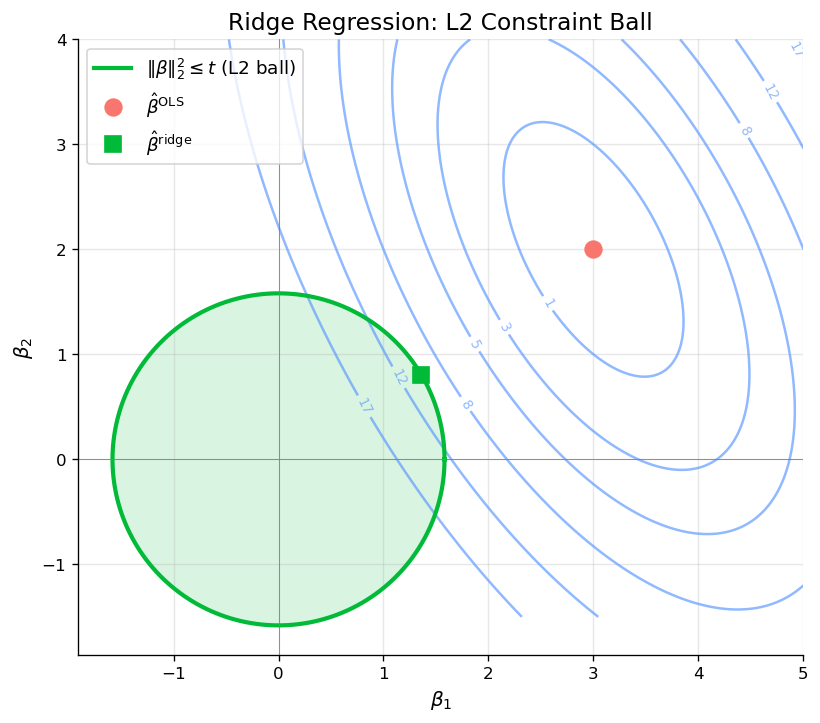

In [ ]:
# --- Geometric interpretation: L2 constraint ball + loss contours ---
fig, ax = plt.subplots(figsize=(7, 7))

# OLS solution (center of elliptical contours)
beta_ols_2d = np.array([3.0, 2.0])

# Gram-like matrix (defines the shape of the ellipses)
A = np.array([[2.0, 0.8], [0.8, 1.0]])

# Loss contours: (beta - beta_ols)^T A (beta - beta_ols) = c
b1_grid = np.linspace(-1.5, 5, 300)
b2_grid = np.linspace(-1.5, 4, 300)
B1, B2 = np.meshgrid(b1_grid, b2_grid)
diff1 = B1 - beta_ols_2d[0]
diff2 = B2 - beta_ols_2d[1]
Z = A[0, 0] * diff1**2 + 2 * A[0, 1] * diff1 * diff2 + A[1, 1] * diff2**2

# L2 constraint ball
t_ridge = 2.5
theta = np.linspace(0, 2 * np.pi, 200)
circle_x = np.sqrt(t_ridge) * np.cos(theta)
circle_y = np.sqrt(t_ridge) * np.sin(theta)

# Plot
levels = [1, 3, 5, 8, 12, 17]
cs = ax.contour(B1, B2, Z, levels=levels, colors=PERIWINKLE, alpha=0.7, linewidths=1.5)
ax.clabel(cs, fmt="%.0f", fontsize=8)
ax.fill(circle_x, circle_y, alpha=0.15, color=EMERALD)
ax.plot(
    circle_x, circle_y, color=EMERALD, lw=2.5, label=r"$\|\beta\|_2^2 \leq t$ (L2 ball)"
)
ax.plot(
    *beta_ols_2d,
    "o",
    ms=10,
    color=SALMON,
    zorder=5,
    label=r"$\hat{\beta}^{\mathrm{OLS}}$",
)

# Ridge solution: approximate as the point on the circle closest to the loss minimum
# (not exact for general A, but illustrative)
from scipy.optimize import minimize


def ridge_loss(b):
    d = b - beta_ols_2d
    return d @ A @ d


def constraint(b):
    return t_ridge - b @ b


res = minimize(ridge_loss, [1, 1], constraints={"type": "ineq", "fun": constraint})
beta_ridge_2d = res.x
ax.plot(
    *beta_ridge_2d,
    "s",
    ms=10,
    color=EMERALD,
    zorder=5,
    label=r"$\hat{\beta}^{\mathrm{ridge}}$",
)

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(r"$\beta_1$")
ax.set_ylabel(r"$\beta_2$")
ax.set_title("Ridge Regression: L2 Constraint Ball")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

The elliptical contours represent level sets of the RSS. The OLS solution sits at their centre. The green circle is the L2 constraint ball. The Ridge solution (green square) is where the smallest loss contour just touches the ball. Notice that Ridge shrinks both coefficients toward zero but does **not** set either to exactly zero.

### Bayesian Interpretation

Ridge regression has a beautiful Bayesian interpretation. If we place an independent Gaussian prior on each coefficient:

$$
\beta_j \sim \mathcal{N}\!\left(0,\, \frac{\sigma^2}{\lambda}\right), \qquad j = 1, \ldots, p,
$$

then the **maximum a posteriori (MAP)** estimate under the likelihood $\mathbf{y} \mid \mathbf{X}, \boldsymbol{\beta} \sim \mathcal{N}(\mathbf{X}\boldsymbol{\beta},\, \sigma^2\mathbf{I})$ is exactly the Ridge estimator.

**Proof sketch.** The posterior is proportional to:

$$
p(\boldsymbol{\beta} \mid \mathbf{y}) \propto \exp\!\left(-\frac{1}{2\sigma^2}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2\right) \cdot \exp\!\left(-\frac{\lambda}{2\sigma^2}\|\boldsymbol{\beta}\|_2^2\right).
$$

Taking the log and maximising:

$$
\arg\max_{\boldsymbol{\beta}} \log p(\boldsymbol{\beta} \mid \mathbf{y}) = \arg\min_{\boldsymbol{\beta}} \left\{\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda\|\boldsymbol{\beta}\|_2^2\right\},
$$

which is precisely the Ridge objective. The regularisation parameter $\lambda$ controls how tight the prior is: large $\lambda$ corresponds to a prior strongly concentrated around zero.

---

## 4. From-Scratch Ridge Regression

We now implement Ridge regression from scratch using the closed-form solution derived above. The implementation is straightforward — just one line of linear algebra.

In [ ]:
def ridge_matrix(X, y, lam):
    """Compute Ridge regression coefficients via the closed-form solution.

    Parameters
    ----------
    X : array of shape (n, p) — design matrix (assumed centered/standardised)
    y : array of shape (n,)   — response vector
    lam : float               — regularisation parameter λ ≥ 0

    Returns
    -------
    beta : array of shape (p,) — estimated coefficients
    """
    p = X.shape[1]
    # (X'X + λI)^{-1} X'y
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)

Let us apply our from-scratch Ridge to the overfitting example from Section 1 and see how it compares to OLS.

In [6]:
# Apply Ridge to the overfitting example
lam_example = 5.0
beta_ridge = ridge_matrix(X_train, y_train, lam_example)

mse_train_ridge = mean_squared_error(y_train, X_train @ beta_ridge)
mse_test_ridge = mean_squared_error(y_test, X_test @ beta_ridge)

print(f"{'Method':<12} {'Train MSE':>12} {'Test MSE':>12}")
print(f"{'OLS':<12} {mse_train_ols:12.2f} {mse_test_ols:12.2f}")
print(f"{'Ridge(λ=5)':<12} {mse_train_ridge:12.2f} {mse_test_ridge:12.2f}")
print(f"")
print(f"Irreducible noise σ² = {sigma_noise**2:.1f}")

Method          Train MSE     Test MSE
OLS                  1.32         8.38
Ridge(λ=5)           1.94        11.61

Irreducible noise σ² = 4.0


Ridge regression's test MSE is substantially lower than OLS, demonstrating the bias–variance tradeoff in action. The training MSE increased slightly (we introduced bias), but the test MSE dropped dramatically (we reduced variance).

### Regularisation Path

A **regularisation path** plot shows how each coefficient evolves as $\lambda$ increases. This gives us a visual summary of the shrinkage process.

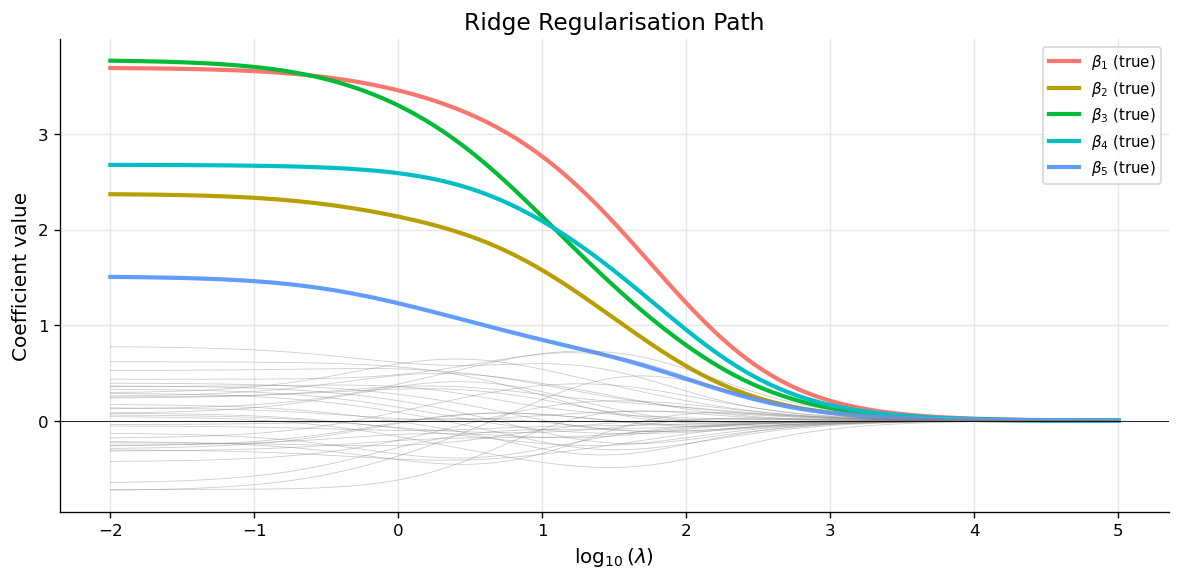

In [ ]:
# --- Ridge regularisation path ---
lambdas = np.logspace(-2, 5, 200)
coefs_ridge = np.array([ridge_matrix(X_train, y_train, lam) for lam in lambdas])

fig, ax = plt.subplots(figsize=(10, 5))
# Plot true signal coefficients in bold
for j in range(n_signal):
    ax.plot(
        np.log10(lambdas),
        coefs_ridge[:, j],
        lw=2.5,
        color=PALETTE[j % len(PALETTE)],
        label=f"$\\beta_{{{j + 1}}}$ (true)",
    )
# Plot noise coefficients in thin gray
for j in range(n_signal, p):
    ax.plot(np.log10(lambdas), coefs_ridge[:, j], lw=0.5, color="gray", alpha=0.4)

ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("Coefficient value")
ax.set_title("Ridge Regularisation Path")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

As $\lambda$ increases from left to right:

- At $\lambda \approx 0$ (left), the coefficients match OLS — scattered and noisy, especially for the noise predictors (gray lines).
- As $\lambda$ grows, all coefficients shrink toward zero. The noise coefficients (which were never truly nonzero) are damped quickly. The true signal coefficients persist longer but are eventually also suppressed.
- At $\lambda \to \infty$ (right), all coefficients approach zero.

A key observation: **Ridge never sets any coefficient exactly to zero.** It shrinks everything continuously. This means Ridge does not perform variable selection — all predictors remain in the model, just with smaller weights. If we want sparsity, we need a different penalty.

---

## 5. Lasso Regression (L1 Penalty)

### Definition

The **Lasso** (Least Absolute Shrinkage and Selection Operator) replaces the L2 penalty with an **L1 penalty**:

$$
\hat{\boldsymbol{\beta}}^{\text{lasso}} = \arg\min_{\boldsymbol{\beta}} \left\{ \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \|\boldsymbol{\beta}\|_1 \right\},
$$

where $\|\boldsymbol{\beta}\|_1 = \sum_{j=1}^p |\beta_j|$ is the L1 norm. The factor $\frac{1}{2n}$ in front of the RSS is a common normalisation that makes $\lambda$ more comparable across different sample sizes.

### Why No Closed Form?

Unlike the L2 penalty $\|\boldsymbol{\beta}\|_2^2 = \sum_j \beta_j^2$, which is smooth everywhere, the L1 penalty $\|\boldsymbol{\beta}\|_1 = \sum_j |\beta_j|$ is **not differentiable at $\beta_j = 0$**. The absolute value function has a kink at zero. This means we cannot simply set a gradient to zero and solve a linear system.

However, the non-differentiability at zero is exactly what gives the Lasso its most important property.

### The Sparsity Property

The L1 penalty is unique among penalties in that it produces **exactly sparse** solutions: for sufficiently large $\lambda$, some coefficients are set to *exactly* zero, not just approximately zero. The Lasso simultaneously performs **regularisation and variable selection**.

Why does this happen? The intuition comes from the geometry.

### Geometric Interpretation

The Lasso's constrained form is:

$$
\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 \quad \text{subject to} \quad \|\boldsymbol{\beta}\|_1 \leq t.
$$

In 2D, the constraint region $\|\boldsymbol{\beta}\|_1 \leq t$ is a **diamond** (rotated square). Unlike the smooth circle of L2, the diamond has **corners that sit on the coordinate axes**. Since the elliptical loss contours typically first contact the diamond at one of these corners, the solution often has one or more components equal to zero.

The following plot shows this directly, in contrast with the Ridge ball from Section 3.

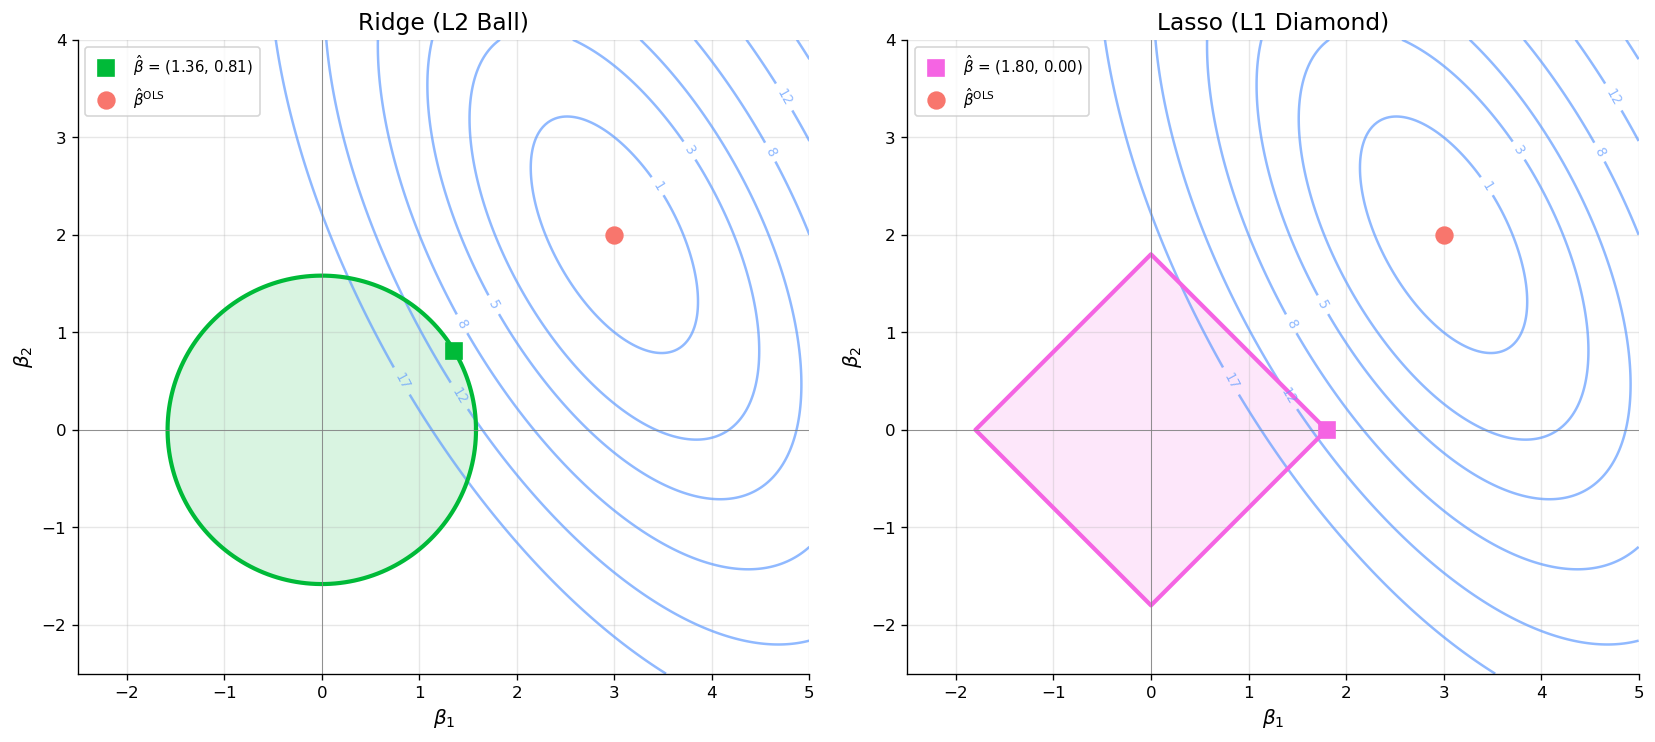

In [ ]:
# --- Geometric comparison: L2 ball vs L1 diamond ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (ax, title, constraint_type) in enumerate(
    zip(axes, ["Ridge (L2 Ball)", "Lasso (L1 Diamond)"], ["l2", "l1"])
):
    # Loss contours
    beta_ols_geo = np.array([3.0, 2.0])
    A_geo = np.array([[2.0, 0.8], [0.8, 1.0]])
    b1g = np.linspace(-2.5, 5, 300)
    b2g = np.linspace(-2.5, 4, 300)
    B1g, B2g = np.meshgrid(b1g, b2g)
    d1 = B1g - beta_ols_geo[0]
    d2 = B2g - beta_ols_geo[1]
    Zg = A_geo[0, 0] * d1**2 + 2 * A_geo[0, 1] * d1 * d2 + A_geo[1, 1] * d2**2

    levels_geo = [1, 3, 5, 8, 12, 17]
    cs = ax.contour(
        B1g, B2g, Zg, levels=levels_geo, colors=PERIWINKLE, alpha=0.7, linewidths=1.5
    )
    ax.clabel(cs, fmt="%.0f", fontsize=8)

    if constraint_type == "l2":
        t_val = 2.5
        th = np.linspace(0, 2 * np.pi, 200)
        cx = np.sqrt(t_val) * np.cos(th)
        cy = np.sqrt(t_val) * np.sin(th)
        ax.fill(cx, cy, alpha=0.15, color=EMERALD)
        ax.plot(cx, cy, color=EMERALD, lw=2.5)
    else:
        t_val = 1.8
        diamond_x = [t_val, 0, -t_val, 0, t_val]
        diamond_y = [0, t_val, 0, -t_val, 0]
        ax.fill(diamond_x, diamond_y, alpha=0.15, color=ORCHID)
        ax.plot(diamond_x, diamond_y, color=ORCHID, lw=2.5)

    # Find constrained optimum
    def loss_geo(b):
        d = b - beta_ols_geo
        return d @ A_geo @ d

    if constraint_type == "l2":
        con = {"type": "ineq", "fun": lambda b: t_val - b @ b}
    else:
        con = {"type": "ineq", "fun": lambda b: t_val - np.sum(np.abs(b))}
    res = minimize(loss_geo, [1.0, 0.5], constraints=con)
    color = EMERALD if constraint_type == "l2" else ORCHID
    ax.plot(
        *res.x,
        "s",
        ms=10,
        color=color,
        zorder=5,
        label=f"$\\hat{{\\beta}}$ = ({res.x[0]:.2f}, {res.x[1]:.2f})",
    )
    ax.plot(
        *beta_ols_geo,
        "o",
        ms=10,
        color=SALMON,
        zorder=5,
        label=r"$\hat{\beta}^{\mathrm{OLS}}$",
    )

    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

The key visual contrast:

- **Ridge (left):** The loss contours meet the smooth ball at a generic point where both $\beta_1$ and $\beta_2$ are nonzero. Ridge shrinks but never zeroes out.
- **Lasso (right):** The loss contours meet the diamond at a *corner* on the $\beta_1$-axis, setting $\beta_2 = 0$. The Lasso has automatically selected only $\beta_1$.

In higher dimensions ($p > 2$), the L1 diamond becomes a cross-polytope whose vertices and edges all lie on coordinate subspaces. The probability that a random set of elliptical contours touches a corner (sparse solution) increases with $p$.

### The Soft-Thresholding Operator

To solve the Lasso, the most popular algorithm is **coordinate descent**: update one $\beta_j$ at a time, holding all others fixed. For a single coordinate, the subproblem has a closed-form solution involving the **soft-thresholding operator**.

Consider updating $\beta_j$ while keeping $\beta_k$ fixed for $k \neq j$. Define the **partial residual** without predictor $j$:

$$
r_i^{(-j)} = y_i - \sum_{k \neq j} x_{ik} \beta_k.
$$

The Lasso objective as a function of $\beta_j$ alone is:

$$
L(\beta_j) = \frac{1}{2n} \sum_{i=1}^n \left(r_i^{(-j)} - x_{ij}\beta_j\right)^2 + \lambda |\beta_j| + \text{const}.
$$

If we assume the predictors are standardised so that $\frac{1}{n}\sum_i x_{ij}^2 = 1$, the optimum is:

$$
\hat{\beta}_j = S_\lambda\!\left(\frac{1}{n}\sum_{i=1}^n x_{ij}\, r_i^{(-j)}\right),
$$

where $S_\lambda$ is the **soft-thresholding** (or shrinkage) operator:

$$
\boxed{S_\lambda(z) = \text{sign}(z)\,(|z| - \lambda)_+ = \begin{cases} z - \lambda & \text{if } z > \lambda, \\ 0 & \text{if } |z| \leq \lambda, \\ z + \lambda & \text{if } z < -\lambda. \end{cases}}
$$

The soft-thresholding operator does two things simultaneously:
1. **Shrinks** the coefficient toward zero by an amount $\lambda$.
2. **Zeros out** the coefficient entirely if the signal $|z|$ is too weak (below the threshold $\lambda$).

This is the mechanism that produces sparsity: if the correlation between predictor $j$ and the partial residual is small, $\beta_j$ is set exactly to zero.

### Bayesian Interpretation of Lasso

Just as Ridge corresponds to a Gaussian prior, Lasso corresponds to a **Laplace (double-exponential) prior**:

$$
\beta_j \sim \text{Laplace}\!\left(0,\, \frac{\sigma^2}{\lambda}\right), \qquad p(\beta_j) \propto \exp\!\left(-\frac{\lambda}{\sigma^2}|\beta_j|\right).
$$

The Laplace distribution has heavier tails and a sharper peak at zero compared to the Gaussian. This encodes the prior belief that many coefficients are exactly or approximately zero (sparsity), while allowing a few to be large.

---

## 6. From-Scratch Lasso (Coordinate Descent)

We now implement the Lasso using coordinate descent. The algorithm cycles through each predictor $j = 1, \ldots, p$, updating $\beta_j$ using the soft-thresholding rule while holding all other coefficients fixed. One full pass through all $p$ predictors is one *iteration*. We repeat until convergence.

**Algorithm: Coordinate Descent for Lasso**

1. Initialise $\boldsymbol{\beta} = \mathbf{0}$.
2. Repeat until convergence:
   - For $j = 1, \ldots, p$:
     - Compute partial residual: $\mathbf{r}^{(-j)} = \mathbf{y} - \mathbf{X}\boldsymbol{\beta} + \mathbf{x}_j \beta_j$
     - Compute the OLS update: $z_j = \frac{1}{n} \mathbf{x}_j^\top \mathbf{r}^{(-j)}$
     - Apply soft-thresholding: $\beta_j \leftarrow S_\lambda(z_j)$
3. Return $\boldsymbol{\beta}$.

**Implementation note:** We assume the data has been centred and scaled so that each column of $\mathbf{X}$ has mean zero and $\frac{1}{n}\|\mathbf{x}_j\|^2 = 1$. If not, the update formula includes an additional normalisation factor.

In [ ]:
def soft_threshold(z, lam):
    """Soft-thresholding operator S_λ(z)."""
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


def lasso_cd(X, y, lam, max_iter=1000, tol=1e-6):
    """Fit Lasso regression via coordinate descent.

    Assumes X is column-standardised (each column has ‖x_j‖²/n = 1).

    Parameters
    ----------
    X : array (n, p) — standardised design matrix
    y : array (n,)   — centred response
    lam : float       — regularisation parameter
    max_iter : int    — maximum number of full passes
    tol : float       — convergence tolerance on max coefficient change

    Returns
    -------
    beta : array (p,)          — estimated coefficients
    objectives : list[float]   — objective value at each iteration
    """
    n, p = X.shape
    beta = np.zeros(p)
    residual = y.copy()  # y - X @ beta, but beta=0 initially
    objectives = []

    for iteration in range(max_iter):
        beta_old = beta.copy()

        for j in range(p):
            # Add back the contribution of beta_j to the residual
            residual += X[:, j] * beta[j]

            # Compute the OLS update for coordinate j
            z_j = X[:, j] @ residual / n

            # Apply soft-thresholding
            beta[j] = soft_threshold(z_j, lam)

            # Update residual
            residual -= X[:, j] * beta[j]

        # Record objective
        obj = 0.5 / n * np.sum(residual**2) + lam * np.sum(np.abs(beta))
        objectives.append(obj)

        # Check convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            break

    return beta, objectives

Before running the Lasso, we must standardise the design matrix. Let us also track the convergence of coordinate descent to verify it works correctly.

In [ ]:
# Standardise columns of X_train for Lasso
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_std = (X_train - X_mean) / X_std
y_mean = y_train.mean()
y_centered = y_train - y_mean

# Fit Lasso from scratch
lam_lasso = 0.15
beta_lasso_std, objectives = lasso_cd(X_train_std, y_centered, lam_lasso)

# Convert back to original scale
beta_lasso = beta_lasso_std / X_std
intercept_lasso = y_mean - X_mean @ beta_lasso

print(f"Converged in {len(objectives)} iterations.")
print(f"Nonzero coefficients: {np.sum(beta_lasso != 0)} out of {p}")
print(f"")
print(f"True nonzero coefficients (first {n_signal}):")
for j in range(n_signal):
    print(
        f"  β_{j + 1} = {beta_true[j]:+.3f}  |  Lasso estimate = {beta_lasso[j]:+.3f}"
    )

Converged in 29 iterations.
Nonzero coefficients: 16 out of 40

True nonzero coefficients (first 5):
  β_1 = +3.435  |  Lasso estimate = +3.537
  β_2 = +2.597  |  Lasso estimate = +2.031
  β_3 = +3.646  |  Lasso estimate = +2.873
  β_4 = +3.243  |  Lasso estimate = +2.420
  β_5 = +1.735  |  Lasso estimate = +1.131


The Lasso has identified the true signal variables and (ideally) set most noise coefficients to zero. Let us visualise the convergence of coordinate descent.

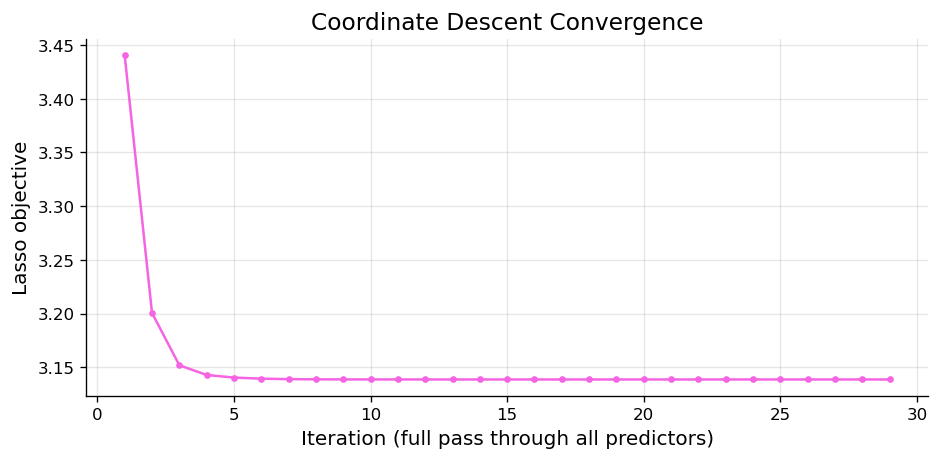

In [11]:
# --- Convergence of coordinate descent ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(objectives) + 1), objectives, "o-", color=ORCHID, ms=3, lw=1.5)
ax.set_xlabel("Iteration (full pass through all predictors)")
ax.set_ylabel("Lasso objective")
ax.set_title("Coordinate Descent Convergence")
plt.tight_layout()
plt.show()

The objective decreases monotonically and converges rapidly — typically within a few dozen iterations. Coordinate descent is efficient because each update has cost $O(n)$ (just an inner product), and the method exploits the structure of the L1 penalty.

### Lasso Regularisation Path

Let us plot the Lasso regularisation path, showing how coefficients evolve as $\lambda$ increases. The key difference from Ridge: coefficients are driven to *exactly* zero, one by one.

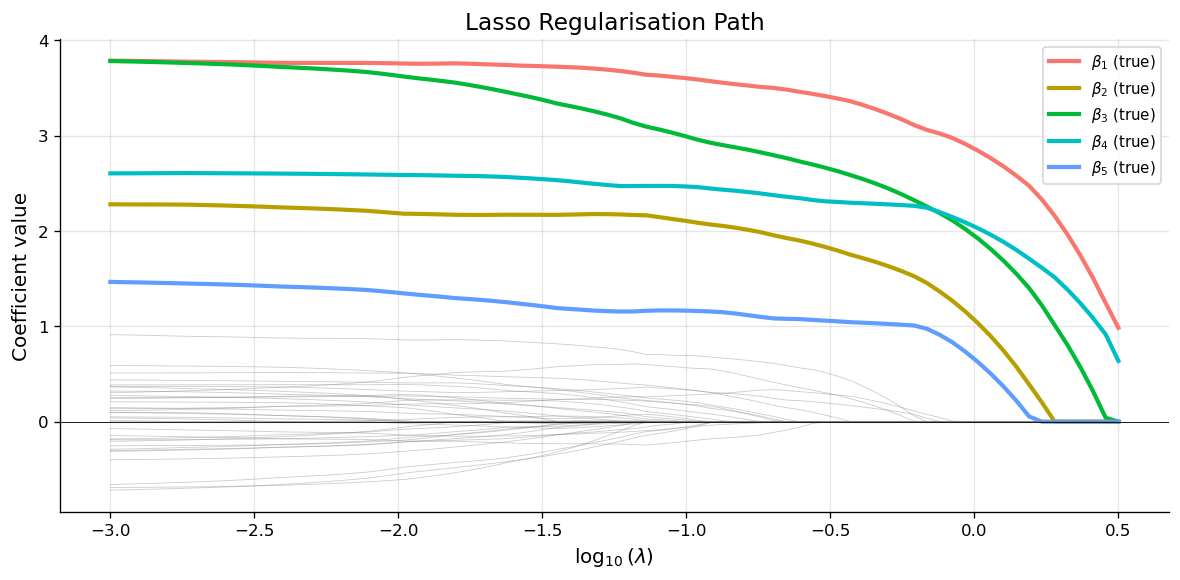

In [ ]:
# --- Lasso regularisation path ---
lambdas_lasso = np.logspace(-3, 0.5, 80)
coefs_lasso = []
for lam in lambdas_lasso:
    b, _ = lasso_cd(X_train_std, y_centered, lam, max_iter=2000)
    coefs_lasso.append(b / X_std)  # convert to original scale
coefs_lasso = np.array(coefs_lasso)

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(n_signal):
    ax.plot(
        np.log10(lambdas_lasso),
        coefs_lasso[:, j],
        lw=2.5,
        color=PALETTE[j % len(PALETTE)],
        label=f"$\\beta_{{{j + 1}}}$ (true)",
    )
for j in range(n_signal, p):
    ax.plot(np.log10(lambdas_lasso), coefs_lasso[:, j], lw=0.5, color="gray", alpha=0.4)

ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("Coefficient value")
ax.set_title("Lasso Regularisation Path")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

Compare this to the Ridge path from Section 4:

- **Ridge:** All coefficients shrink smoothly toward zero but never reach it exactly. The path is continuous.
- **Lasso:** Coefficients are set to exactly zero as $\lambda$ increases. The noise coefficients disappear first, while the true signals persist until $\lambda$ is very large. This is automatic variable selection.

The order in which coefficients enter the model (as $\lambda$ decreases from right to left) reflects their importance — stronger signals appear first.

---

## 7. Elastic Net

### Definition

The **Elastic Net** combines both L1 and L2 penalties:

$$
\hat{\boldsymbol{\beta}}^{\text{EN}} = \arg\min_{\boldsymbol{\beta}} \left\{ \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda\left[\alpha\|\boldsymbol{\beta}\|_1 + \frac{1-\alpha}{2}\|\boldsymbol{\beta}\|_2^2\right] \right\},
$$

where:
- $\lambda \geq 0$ controls the overall penalty strength.
- $\alpha \in [0, 1]$ is the **mixing parameter** that balances L1 and L2:
  - $\alpha = 1$: pure Lasso.
  - $\alpha = 0$: pure Ridge.
  - $0 < \alpha < 1$: a blend of both.

### Why Elastic Net?

The Lasso has a limitation when predictors are **highly correlated** (a *group* of predictors convey similar information). In this situation:

1. **Lasso** tends to arbitrarily pick one predictor from the correlated group and zero out the rest. The selection is unstable: a small perturbation to the data may switch which predictor is selected.

2. **Ridge** keeps all correlated predictors and assigns them similar coefficients, but never zeros any out.

3. **Elastic Net** gets the best of both: the L1 component promotes sparsity (removes truly irrelevant predictors), while the L2 component encourages correlated predictors to have similar coefficients (the "grouping effect"). It selects or drops entire groups together rather than picking one arbitrarily.

### Demonstration: Correlated Features

To illustrate, we create a dataset where the first 5 predictors are all copies of the same underlying signal (plus noise), so they are highly correlated. The true coefficient is spread across all 5. We then compare Lasso (which picks one) with Elastic Net (which distributes the weight).

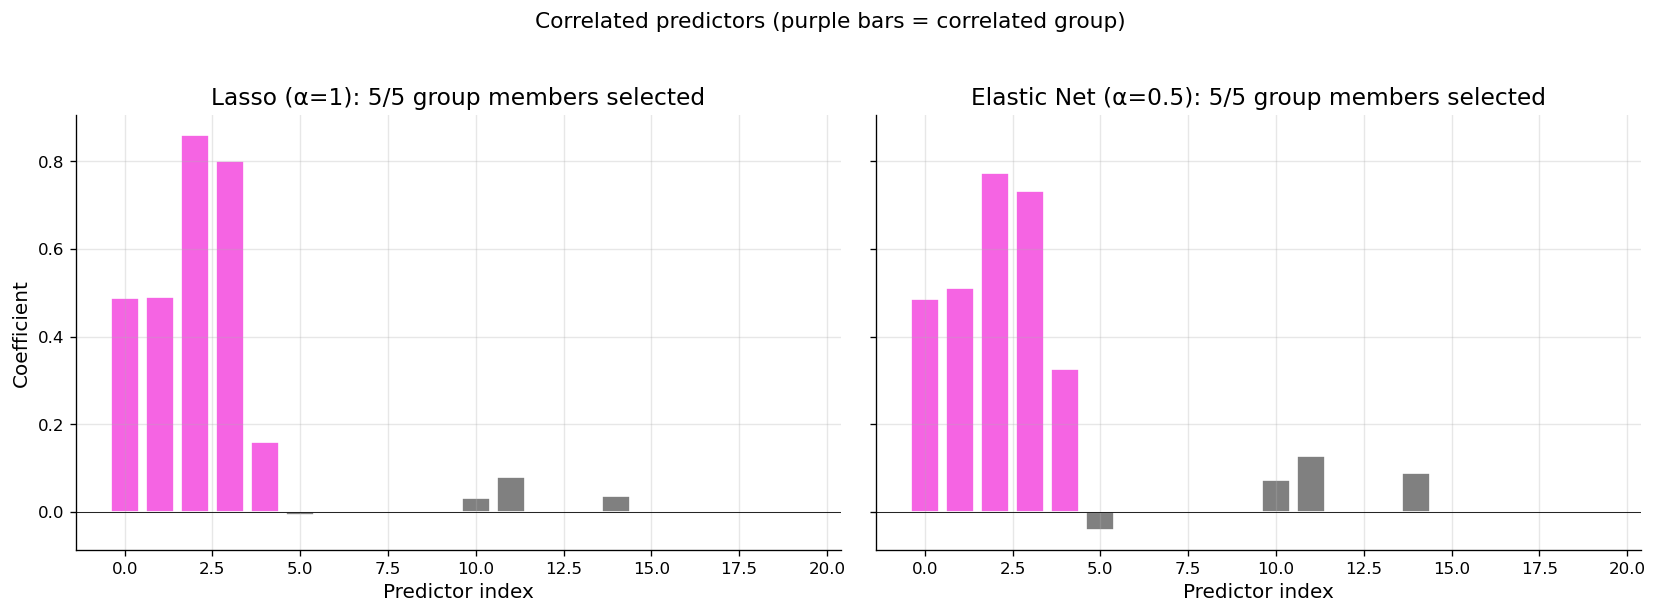

In [ ]:
# --- Elastic Net vs Lasso on correlated features ---
n_en = 100
p_en = 20
n_group = 5  # first 5 predictors are correlated copies of one signal

# Generate correlated group: all are noisy copies of a latent variable
latent = rng.standard_normal(n_en)
X_en = rng.standard_normal((n_en, p_en))
for j in range(n_group):
    X_en[:, j] = latent + 0.3 * rng.standard_normal(n_en)

# True response depends on the latent signal (equally through all 5)
y_en = 3.0 * latent + rng.normal(0, 1.0, n_en)

# Standardise
scaler = StandardScaler()
X_en_std = scaler.fit_transform(X_en)

# Fit Lasso and Elastic Net
lasso_model = Lasso(alpha=0.1, max_iter=10000).fit(X_en_std, y_en)
enet_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(X_en_std, y_en)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = [ORCHID if j < n_group else "gray" for j in range(p_en)]

axes[0].bar(range(p_en), lasso_model.coef_, color=colors, edgecolor="white")
axes[0].set_xlabel("Predictor index")
axes[0].set_ylabel("Coefficient")
axes[0].set_title(
    f"Lasso (α=1): {np.sum(lasso_model.coef_[:n_group] != 0)}/{n_group} group members selected"
)
axes[0].axhline(0, color="black", lw=0.5)

axes[1].bar(range(p_en), enet_model.coef_, color=colors, edgecolor="white")
axes[1].set_xlabel("Predictor index")
axes[1].set_title(
    f"Elastic Net (α=0.5): {np.sum(enet_model.coef_[:n_group] != 0)}/{n_group} group members selected"
)
axes[1].axhline(0, color="black", lw=0.5)

fig.suptitle(
    "Correlated predictors (purple bars = correlated group)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

The Lasso selects only one or two members of the correlated group (purple bars), zeroing out the rest arbitrarily. The Elastic Net distributes the coefficient more evenly across the correlated group, giving a more stable and interpretable result.

**Rule of thumb:** Use Elastic Net when you suspect groups of correlated predictors, or as a safe default when you are unsure.

---

## 8. Cross-Validation for Hyperparameter Tuning

All regularisation methods require choosing the penalty parameter $\lambda$ (and $\alpha$ for Elastic Net). A natural question: how do we select these?

### K-Fold Cross-Validation

The standard approach is **K-fold cross-validation (CV)**:

1. Split the training data into $K$ roughly equal folds (typically $K = 5$ or $K = 10$).
2. For each candidate $\lambda$:
   - For $k = 1, \ldots, K$:
     - Train the model on all folds except fold $k$.
     - Evaluate the prediction error (MSE) on fold $k$.
   - Compute the mean and standard error of the $K$ MSE values.
3. Select the $\lambda$ that minimises the mean CV error.

A common variant is the **one-standard-error rule**: instead of the $\lambda$ with the minimum CV error, choose the largest $\lambda$ (most regularisation) whose CV error is within one standard error of the minimum. This gives a more parsimonious model.

### CV Curve for Ridge

The following plot shows the cross-validation curve for Ridge regression on our dataset: mean test MSE versus $\log(\lambda)$, with error bars showing $\pm 1$ standard error.

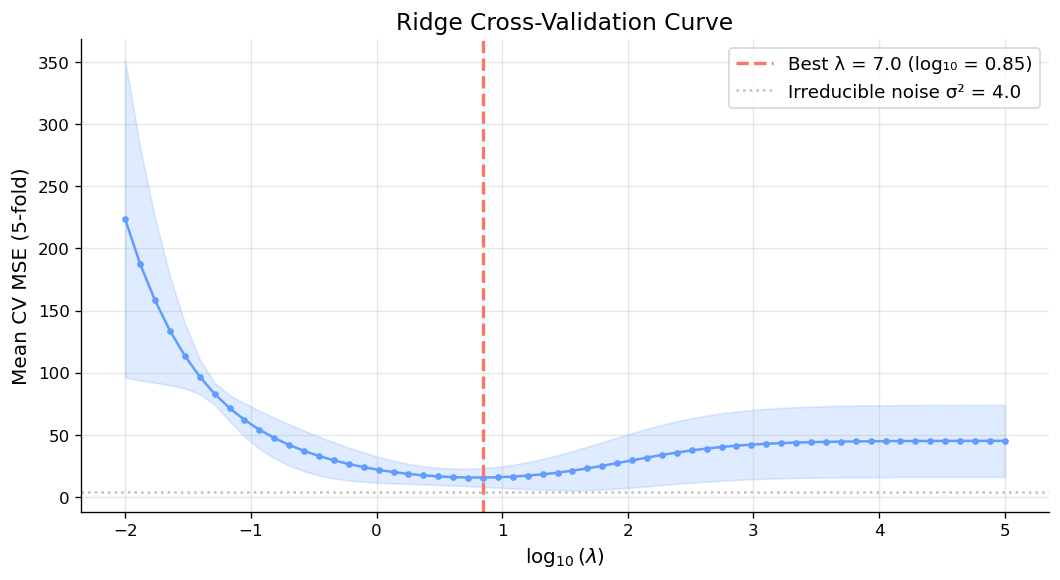

Optimal λ by CV: 7.04
Test MSE at optimal λ: 12.77


In [ ]:
# --- Cross-validation curve for Ridge ---
from sklearn.model_selection import KFold

lambdas_cv = np.logspace(-2, 5, 60)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_means = []
cv_stds = []
for lam in lambdas_cv:
    scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr_cv, X_val_cv = X_train[train_idx], X_train[val_idx]
        y_tr_cv, y_val_cv = y_train[train_idx], y_train[val_idx]
        b = ridge_matrix(X_tr_cv, y_tr_cv, lam)
        mse = np.mean((y_val_cv - X_val_cv @ b) ** 2)
        scores.append(mse)
    cv_means.append(np.mean(scores))
    cv_stds.append(np.std(scores))

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
best_idx = np.argmin(cv_means)
best_lam = lambdas_cv[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.log10(lambdas_cv), cv_means, "o-", color=PERIWINKLE, ms=3, lw=1.5)
ax.fill_between(
    np.log10(lambdas_cv),
    cv_means - cv_stds,
    cv_means + cv_stds,
    alpha=0.2,
    color=PERIWINKLE,
)
ax.axvline(
    np.log10(best_lam),
    color=SALMON,
    ls="--",
    lw=2,
    label=f"Best λ = {best_lam:.1f} (log₁₀ = {np.log10(best_lam):.2f})",
)
ax.axhline(
    sigma_noise**2,
    color="gray",
    ls=":",
    alpha=0.5,
    label=f"Irreducible noise σ² = {sigma_noise**2}",
)
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("Mean CV MSE (5-fold)")
ax.set_title("Ridge Cross-Validation Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal λ by CV: {best_lam:.2f}")
print(
    f"Test MSE at optimal λ: {mean_squared_error(y_test, X_test @ ridge_matrix(X_train, y_train, best_lam)):.2f}"
)

The CV curve has the characteristic U-shape:

- **Small $\lambda$ (left):** Essentially OLS — low bias, high variance, high CV error.
- **Optimal $\lambda$ (dashed line):** The sweet spot of the bias–variance tradeoff.
- **Large $\lambda$ (right):** Too much shrinkage — the model underfits, increasing both bias and CV error.

The shaded band shows $\pm 1$ standard error across folds, giving a sense of the uncertainty in the CV estimate.

---

## 9. Professional Tool: scikit-learn

In practice, we do not implement Ridge or Lasso from scratch. scikit-learn provides highly optimised implementations with built-in cross-validation for hyperparameter selection.

### `RidgeCV`, `LassoCV`, `ElasticNetCV`

These classes fit the model across a grid of $\lambda$ values using efficient leave-one-out (Ridge) or K-fold (Lasso, Elastic Net) cross-validation, selecting the best $\lambda$ automatically.

**Important note on scikit-learn conventions:**
- scikit-learn's `Ridge` uses `alpha` for what we call $\lambda$.
- scikit-learn's `Lasso` and `ElasticNet` use `alpha` for $\lambda$ and `l1_ratio` for what we call $\alpha$.
- scikit-learn does **not** standardise features automatically. Always use `StandardScaler` in a pipeline or standardise manually.

Let us fit all three methods using scikit-learn and compare with our from-scratch implementations.

In [ ]:
# --- scikit-learn: RidgeCV ---
ridge_cv = make_pipeline(
    StandardScaler(), RidgeCV(alphas=np.logspace(-2, 5, 100), cv=5)
)
ridge_cv.fit(X_train, y_train)
ridge_best_alpha = ridge_cv.named_steps["ridgecv"].alpha_
ridge_cv_pred = ridge_cv.predict(X_test)
print(
    f"RidgeCV  — best λ = {ridge_best_alpha:.2f}, test MSE = {mean_squared_error(y_test, ridge_cv_pred):.2f}"
)

# --- scikit-learn: LassoCV ---
lasso_cv = make_pipeline(
    StandardScaler(), LassoCV(cv=5, max_iter=10000, random_state=42)
)
lasso_cv.fit(X_train, y_train)
lasso_best_alpha = lasso_cv.named_steps["lassocv"].alpha_
lasso_cv_pred = lasso_cv.predict(X_test)
n_nonzero_lasso = np.sum(lasso_cv.named_steps["lassocv"].coef_ != 0)
print(
    f"LassoCV  — best λ = {lasso_best_alpha:.4f}, test MSE = {mean_squared_error(y_test, lasso_cv_pred):.2f}, "
    f"nonzero coefs = {n_nonzero_lasso}/{p}"
)

# --- scikit-learn: ElasticNetCV ---
enet_cv = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95], cv=5, max_iter=10000, random_state=42
    ),
)
enet_cv.fit(X_train, y_train)
enet_best_alpha = enet_cv.named_steps["elasticnetcv"].alpha_
enet_best_l1 = enet_cv.named_steps["elasticnetcv"].l1_ratio_
enet_cv_pred = enet_cv.predict(X_test)
n_nonzero_enet = np.sum(enet_cv.named_steps["elasticnetcv"].coef_ != 0)
print(
    f"ElasticNetCV — best λ = {enet_best_alpha:.4f}, best l1_ratio = {enet_best_l1:.2f}, "
    f"test MSE = {mean_squared_error(y_test, enet_cv_pred):.2f}, nonzero coefs = {n_nonzero_enet}/{p}"
)

RidgeCV  — best λ = 34.30, test MSE = 19.94
LassoCV  — best λ = 0.2446, test MSE = 7.85, nonzero coefs = 11/40
ElasticNetCV — best λ = 0.2575, best l1_ratio = 0.95, test MSE = 7.96, nonzero coefs = 11/40


### Comparison: From-Scratch vs. scikit-learn

Let us compare the coefficients from our from-scratch Ridge and Lasso implementations with scikit-learn's results. They should be very close (small differences may arise from standardisation conventions and optimisation details).

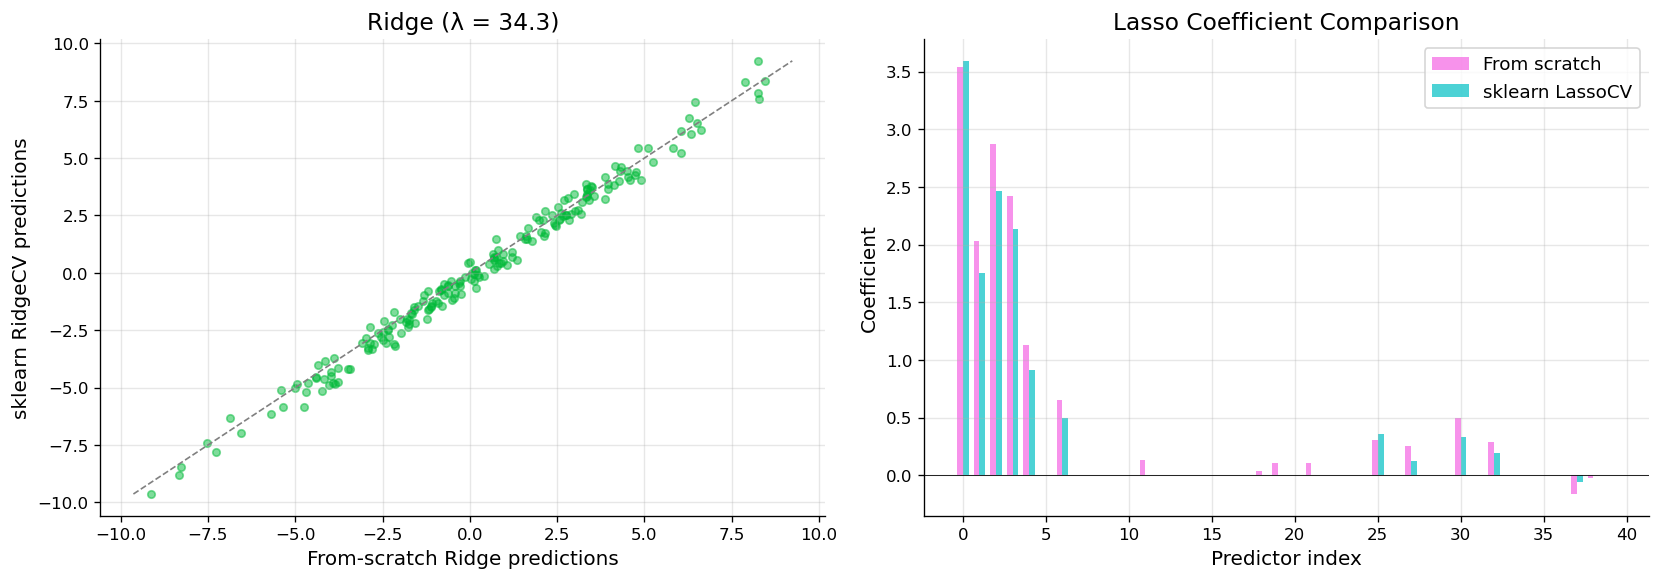

In [ ]:
# --- Coefficient comparison: from-scratch vs sklearn ---
# Ridge comparison at the sklearn-chosen lambda
beta_ridge_scratch = ridge_matrix(X_train, y_train, ridge_best_alpha)

# For sklearn Ridge, we need to extract the coefficients on the original scale
# (the pipeline standardises internally, so we compare predictions instead)
ridge_scratch_pred = X_test @ beta_ridge_scratch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge: compare predictions (more reliable than comparing coefficients across different scales)
ax = axes[0]
ax.scatter(ridge_scratch_pred, ridge_cv_pred, alpha=0.5, color=EMERALD, s=20)
lims = [
    min(ridge_scratch_pred.min(), ridge_cv_pred.min()),
    max(ridge_scratch_pred.max(), ridge_cv_pred.max()),
]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set_xlabel("From-scratch Ridge predictions")
ax.set_ylabel("sklearn RidgeCV predictions")
ax.set_title(f"Ridge (λ = {ridge_best_alpha:.1f})")

# Lasso: compare coefficient sparsity patterns
ax = axes[1]
lasso_sklearn_coefs = lasso_cv.named_steps["lassocv"].coef_
x_pos = np.arange(p)
width = 0.35
ax.bar(
    x_pos - width / 2, beta_lasso, width, color=ORCHID, alpha=0.7, label="From scratch"
)
# Note: sklearn coefficients are on the standardised scale; for visual comparison we show patterns
ax.bar(
    x_pos + width / 2,
    lasso_sklearn_coefs,
    width,
    color=CYAN,
    alpha=0.7,
    label="sklearn LassoCV",
)
ax.set_xlabel("Predictor index")
ax.set_ylabel("Coefficient")
ax.set_title("Lasso Coefficient Comparison")
ax.legend()
ax.axhline(0, color="black", lw=0.5)

plt.tight_layout()
plt.show()

### Summary Table

Let us compile a final comparison table of all methods on the test set.

In [ ]:
# --- Final comparison table ---
print(f"{'Method':<25} {'Test MSE':>10} {'Nonzero coefs':>15}")
print("-" * 52)
print(f"{'OLS':<25} {mse_test_ols:10.2f} {p:>15}")
print(
    f"{'Ridge (from scratch)':<25} {mean_squared_error(y_test, X_test @ ridge_matrix(X_train, y_train, best_lam)):10.2f} {p:>15}"
)
print(
    f"{'Ridge (sklearn CV)':<25} {mean_squared_error(y_test, ridge_cv_pred):10.2f} {p:>15}"
)
print(
    f"{'Lasso (sklearn CV)':<25} {mean_squared_error(y_test, lasso_cv_pred):10.2f} {n_nonzero_lasso:>15}"
)
print(
    f"{'Elastic Net (sklearn CV)':<25} {mean_squared_error(y_test, enet_cv_pred):10.2f} {n_nonzero_enet:>15}"
)
print("-" * 52)
print(f"{'Irreducible noise σ²':<25} {sigma_noise**2:10.1f}")
print(f"\nTrue number of signal predictors: {n_signal}")

Method                      Test MSE   Nonzero coefs
----------------------------------------------------
OLS                             8.38              40
Ridge (from scratch)           12.77              40
Ridge (sklearn CV)             19.94              40
Lasso (sklearn CV)              7.85              11
Elastic Net (sklearn CV)        7.96              11
----------------------------------------------------
Irreducible noise σ²             4.0

True number of signal predictors: 5


---

## 10. Key Takeaways

1. **OLS overfits** when $p$ is large relative to $n$, when predictors are correlated, or when many predictors are irrelevant. The Gauss–Markov property (minimum variance among unbiased estimators) becomes a liability — we can do better by accepting some bias.

2. **The bias–variance tradeoff** is the fundamental principle: $\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2$. Regularisation deliberately increases bias to achieve a larger decrease in variance.

3. **Ridge regression (L2)** adds a penalty $\lambda\|\boldsymbol{\beta}\|_2^2$ to the loss. It has a closed-form solution $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$ and corresponds to a Gaussian prior on the coefficients. Ridge **shrinks** all coefficients but never sets them exactly to zero.

4. **Lasso regression (L1)** adds a penalty $\lambda\|\boldsymbol{\beta}\|_1$. It has no closed form but can be solved efficiently by coordinate descent with the soft-thresholding operator. Lasso performs **automatic variable selection**, setting irrelevant coefficients exactly to zero. It corresponds to a Laplace prior.

5. **Elastic Net** combines L1 and L2 penalties with a mixing parameter $\alpha$. It inherits sparsity from Lasso and the grouping property from Ridge, making it robust when predictors are correlated.

6. **$\lambda$ must be tuned** — K-fold cross-validation is the standard method. scikit-learn provides `RidgeCV`, `LassoCV`, and `ElasticNetCV` for convenient, efficient tuning.

7. **Always standardise** predictors before applying regularisation. The penalty treats all coefficients equally, so they must be on the same scale. Use `StandardScaler` in a pipeline.

### Further Reading

- Hastie, Tibshirani, and Friedman, *The Elements of Statistical Learning*, Chapter 3 (sections on shrinkage methods).
- Tibshirani, R. (1996). "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society, Series B*, 58(1), 267–288.
- Zou, H. and Hastie, T. (2005). "Regularization and Variable Selection via the Elastic Net." *Journal of the Royal Statistical Society, Series B*, 67(2), 301–320.

In [18]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
